## Solana training for XGBoost model

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

random.seed(42)
np.random.seed(42)

In [2]:
sol_df_xgb = pd.read_csv(r'feature_datasets\SOL_features.csv', parse_dates=True, index_col=0)

print(sol_df_xgb.shape)
sol_df_xgb.head()

(916, 30)


,Close,High,Low,Open,Volume,Daily_Return,Close_Lag_1,Close_Lag_7,Close_Lag_14,Close_Lag_30,...,HL_Spread,Volume_MA_7,Volume_MA_21,Volume_MA_60,Volume_MA_180,Volume_Change,Target_Return_7,Target_Return_30,Target_Return_365,Target_Up
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-30,35.556404,35.954723,31.601351,33.962971,570984168.0,0.049890,33.866802,30.048887,39.703617,32.816246,...,4.353373,5.496213e+08,5.862805e+08,8.554070e+08,4.633669e+08,0.210086,0.029108,-0.088942,-0.055348,1
2021-07-01,33.404034,35.538193,32.386272,35.505653,474665321.0,-0.060534,35.556404,31.181034,39.264591,30.985260,...,3.151920,5.258377e+08,5.805385e+08,8.538002e+08,4.658279e+08,-0.168689,-0.005996,0.102481,-0.017991,0
2021-07-02,34.020481,34.031788,31.479923,33.306309,440298780.0,0.018454,33.404034,28.698862,36.648796,33.956318,...,2.551865,4.984444e+08,5.768067e+08,8.509853e+08,4.679681e+08,-0.072402,-0.022217,0.006875,-0.019432,0
2021-07-03,34.478817,35.404770,33.298473,34.015575,327019964.0,0.013472,34.020481,29.712854,35.353436,39.470905,...,2.106297,4.651126e+08,5.662329e+08,8.450527e+08,4.694518e+08,-0.257277,-0.078024,-0.036440,-0.031697,0
2021-07-04,34.310600,35.502373,33.555737,34.495117,303420520.0,-0.004879,34.478817,31.929392,35.322014,37.415070,...,1.946636,4.374079e+08,5.591106e+08,8.417133e+08,4.708566e+08,-0.072165,-0.062160,-0.009156,0.072119,0


In [3]:
# Target = next-day Close
sol_y_xgb = sol_df_xgb['Close'].shift(-1)

# Features = all columns except Close
sol_X_xgb = sol_df_xgb.drop(columns=['Close'])

# Drop last row because shifted target becomes NaN
sol_X_xgb = sol_X_xgb.iloc[:-1]
sol_y_xgb = sol_y_xgb.iloc[:-1]

print("SOL X shape:", sol_X_xgb.shape)
print("SOL y shape:", sol_y_xgb.shape)

SOL X shape: (915, 29)
SOL y shape: (915,)


In [4]:
split_idx = int(len(sol_X_xgb) * 0.7)

sol_X_train_xgb = sol_X_xgb.iloc[:split_idx]
sol_X_test_xgb = sol_X_xgb.iloc[split_idx:]

sol_y_train_xgb = sol_y_xgb.iloc[:split_idx]
sol_y_test_xgb = sol_y_xgb.iloc[split_idx:]

print("X_train shape:", sol_X_train_xgb.shape)
print("X_test shape:", sol_X_test_xgb.shape)
print("y_train shape:", sol_y_train_xgb.shape)
print("y_test shape:", sol_y_test_xgb.shape)

X_train shape: (640, 29)
X_test shape: (275, 29)
y_train shape: (640,)
y_test shape: (275,)


In [5]:
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model_xgb.fit(sol_X_train_xgb, sol_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
sol_preds_xgb = model_xgb.predict(sol_X_test_xgb)

print("Predictions shape:", sol_preds_xgb.shape)
print("First 10 predictions:", sol_preds_xgb[:10])

Predictions shape: (275,)
First 10 predictions: [21.14535  20.64257  20.321548 20.464832 20.764061 20.264595 20.372944
 19.674198 20.012424 20.28616 ]


In [7]:
mse_xgb = mean_squared_error(sol_y_test_xgb, sol_preds_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(sol_y_test_xgb, sol_preds_xgb)
r2_xgb = r2_score(sol_y_test_xgb, sol_preds_xgb)
mape_xgb = np.mean(np.abs((sol_y_test_xgb - sol_preds_xgb) / sol_y_test_xgb)) * 100

print("XGBoost Results:")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

XGBoost Results:
MSE: 27.70
RMSE: 5.26
MAE: 3.25
R2 Score: 0.9438
MAPE: 8.48%


In [8]:
results_xgb = pd.DataFrame({
    "Actual": sol_y_test_xgb.values,
    "Predicted": sol_preds_xgb
})

results_xgb.head()

,Actual,Predicted
0,20.536976,21.145350
1,20.443050,20.642570
2,20.924620,20.321548
3,20.966007,20.464832
4,20.610128,20.764061


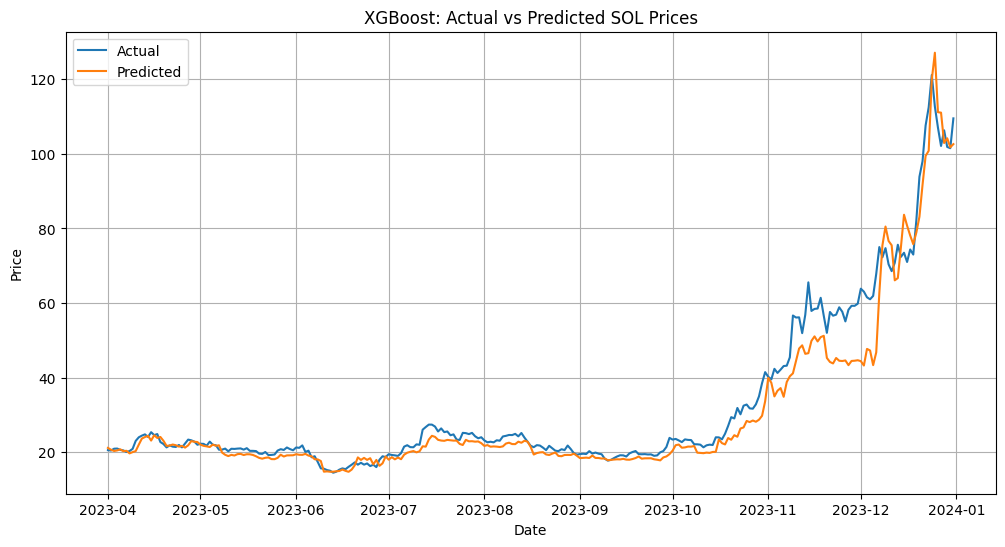

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(sol_y_test_xgb.index,sol_y_test_xgb.values, label="Actual")
plt.plot(sol_y_test_xgb.index,sol_preds_xgb, label="Predicted")
plt.title("XGBoost: Actual vs Predicted SOL Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

              Feature  Importance
1                 Low    0.425356
0                High    0.409892
2                Open    0.096554
5         Close_Lag_1    0.017014
27  Target_Return_365    0.015406
14             MA_180    0.009308
11               MA_7    0.005392
13              MA_60    0.003212
21       Volume_MA_21    0.002239
22       Volume_MA_60    0.001894


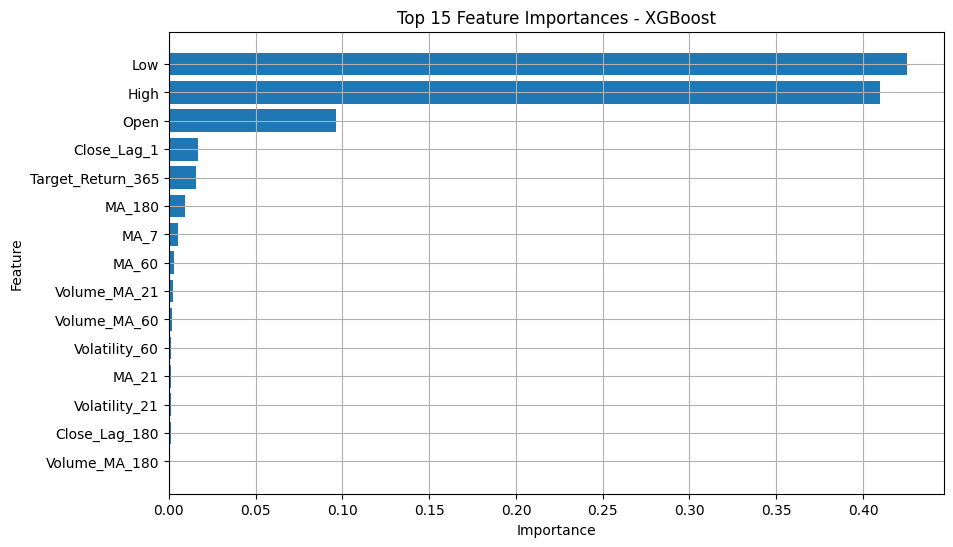

In [10]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": sol_X_train_xgb.columns,
    "Importance": model_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"].head(15)[::-1], importance["Importance"].head(15)[::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

## Finetuning Xgboost model

In [11]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    model_xgb_opt = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb_opt.fit(sol_X_train_xgb, sol_y_train_xgb)

    preds_xgb_opt = model_xgb_opt.predict(sol_X_test_xgb)

    rmse_xgb_opt = np.sqrt(mean_squared_error(sol_y_test_xgb, preds_xgb_opt))
    return rmse_xgb_opt

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
study_xgb = optuna.create_study(
    direction="minimize",
    study_name="xgb_optuna_sol",
    storage="sqlite:///xgb_optuna_sol.db",
    load_if_exists=True
)

study_xgb.optimize(objective, n_trials=50)

[I 2026-04-14 16:31:29,427] Using an existing study with name 'xgb_optuna_sol' instead of creating a new one.
[I 2026-04-14 16:31:31,057] Trial 50 finished with value: 6.062374376582725 and parameters: {'n_estimators': 329, 'max_depth': 5, 'learning_rate': 0.012203476792508165, 'subsample': 0.9176059783673398, 'colsample_bytree': 0.893332060130814}. Best is trial 16 with value: 3.0002628943193805.
[I 2026-04-14 16:31:32,294] Trial 51 finished with value: 3.22745235147497 and parameters: {'n_estimators': 299, 'max_depth': 3, 'learning_rate': 0.036935329565744045, 'subsample': 0.6814972660616139, 'colsample_bytree': 0.9955801013325258}. Best is trial 16 with value: 3.0002628943193805.
[I 2026-04-14 16:31:33,027] Trial 52 finished with value: 3.4424154689889033 and parameters: {'n_estimators': 234, 'max_depth': 3, 'learning_rate': 0.02538624516481718, 'subsample': 0.6228498530672579, 'colsample_bytree': 0.9770054549609011}. Best is trial 16 with value: 3.0002628943193805.
[I 2026-04-14 16

In [13]:
print("Best XGBoost RMSE:", study_xgb.best_value)
print("Best XGBoost Parameters:", study_xgb.best_params)

Best XGBoost RMSE: 2.92202606639352
Best XGBoost Parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.04075540040207477, 'subsample': 0.6334830688293686, 'colsample_bytree': 0.6310287563377533}


In [14]:
best_params_xgb = study_xgb.best_params

model_xgb_best = XGBRegressor(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    colsample_bytree=best_params_xgb["colsample_bytree"],
    objective="reg:squarederror",
    random_state=42
)

model_xgb_best.fit(sol_X_train_xgb, sol_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6310287563377533
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [15]:
sol_preds_xgb_best = model_xgb_best.predict(sol_X_test_xgb)

print("Predictions shape:", sol_preds_xgb_best.shape)
print("First 10 predictions:", sol_preds_xgb_best[:10])

Predictions shape: (275,)
First 10 predictions: [22.09722  21.769314 21.76018  21.955927 22.09658  22.045074 21.822258
 21.76018  21.955927 21.955927]


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_xgb_best = mean_squared_error(sol_y_test_xgb, sol_preds_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
mae_xgb_best = mean_absolute_error(sol_y_test_xgb, sol_preds_xgb_best)
r2_xgb_best = r2_score(sol_y_test_xgb, sol_preds_xgb_best)
mape_xgb_best = np.mean(np.abs((sol_y_test_xgb - sol_preds_xgb_best) / sol_y_test_xgb)) * 100

print("Best XGBoost Results:")
print(f"MSE: {mse_xgb_best:.2f}")
print(f"RMSE: {rmse_xgb_best:.2f}")
print(f"MAE: {mae_xgb_best:.2f}")
print(f"R2 Score: {r2_xgb_best:.4f}")
print(f"MAPE: {mape_xgb_best:.2f}%")

Best XGBoost Results:
MSE: 8.54
RMSE: 2.92
MAE: 1.79
R2 Score: 0.9827
MAPE: 5.09%


In [17]:
import joblib

# Save model
joblib.dump(model_xgb_best, "Solana_Final.pkl")

print("✅ SOL XGBoost model saved successfully!")

✅ SOL XGBoost model saved successfully!
